# UNET - F2 - AmaroXI - 1.2 M

## Libraries

In [1]:
from AmaroXI.AmaroX.ai_functions import * 
from AmaroXI.AmaroX.UNET import * 
from AmaroXI.AmaroX.data_manipulation import *
from AmaroXI.AmaroX.utilities import *
from AmaroXI.AmaroX.DNN import *

2025-10-11 00:25:11.018506: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-11 00:25:11.822452: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/intel/oneapi/vtune/2023.2.0/lib64/:/opt/gaussian//g16/bsd:/opt/gaussian//g16:/opt/TeraChem/TeraChem/lib:/usr/local/cuda/lib64:/opt/intel/oneapi/vtune/2023.2.0/lib64/:/opt/intel/oneapi/tbb/2021.10.0/env/../lib/intel64/gcc4.8:/opt/intel/oneapi/mpi/2021.10.0//libfabric/lib:/opt/intel/oneapi/mpi/2021.10.0//lib/release:/opt/intel/oneapi/mpi/2021.10.0//lib:/opt/intel/oneapi/mkl/2023.2.0/lib/

## Load Data

In [2]:
n = 1
size = [
    1080000//n,
    108000//n, 
    12000//n
]

In [3]:
data = load_data_normalization_sample_General(
    folder = '../../../0_data_simulation/F145F',
    size = size
)

In [4]:
show_dimensions(data)


--------------------------------------------------
The dimensions of each dataset corresponds to:
--------------------------------------------------

Train: 
    x: (1080000, 911, 1)
    y: (1080000, 1)

Test: 
    x: (108000, 911, 1)
    y: (108000, 1)

Val:
    x: (12000, 911, 1)
    y: (12000, 1)
    


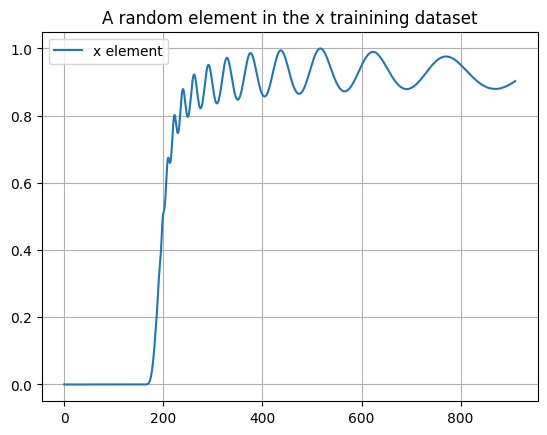

The corresponding y element -> [1216.4795]


In [5]:
plot_xy(data)

In [6]:
x_train, y_train, x_test, y_test, x_val, y_val = data
del data 

## GPU Allocation

In [7]:
#! nvidia-smi

In [8]:
get_gpu(2)

2025-10-11 00:25:41.262263: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-11 00:25:42.102394: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30971 MB memory:  -> device: 2, name: Tesla V100-PCIE-32GB, pci bus id: 0000:86:00.0, compute capability: 7.0


## Paths

In [9]:
name = 'UNET-F145F2'
folder_path = './models'
final_path = os.path.join(folder_path, name)

## Callbacks

In [10]:
callbacks = standard_callbacks(folder_name= name, 
                               folder_path= folder_path,
                               monitor='val_mape',
                               flow_direction= 'min',
                               patiences= [1000, 1000],) # EarlyStopping and ReduceLR are deactivated

## Seed

In [11]:
keras.utils.set_random_seed(13)

## UNET Model

In [12]:
G_UNET

<function AmaroXI.AmaroX.UNET.G_UNET(inputs: tensorflow.python.framework.ops.Tensor, layers: int, unet_kernel: list, WIC: str, WRC, pad_type: str, unet_act_func='leaky_relu', pool: int = 12, stride: int = 3, final_func_act: str = 'relu', stride_conv: int = 1, pool_op: str = 'AP', pool_bool: bool = True)>

In [13]:
G_Dense

<function AmaroXI.AmaroX.DNN.G_Dense(inputs: tensorflow.python.framework.ops.Tensor, nodes: list, DP: int, n_final: int, act_func: str = 'leaky_relu', final_act_func: str = 'softmax', WI: str = 'he_normal', L1: float = 0.0, L2: float = 0.0, use_bias: bool = False) -> tensorflow.python.framework.ops.Tensor>

In [14]:
def _UNET():

    inputs = keras.layers.Input( (911,1) )

    _UNET = G_UNET(
        inputs = inputs, 
        layers = 21, 
        unet_kernel = [150, 50, 5], 
        WIC = 'he_normal', 
        WRC = keras.regularizers.L1L2(l1 = 1e-6 , l2= 1e-4), 
        pad_type = 'valid', 
        unet_act_func= 'leaky_relu', 
        pool = 4, 
        stride = 4, 
        final_func_act= 'leaky_relu', 
        stride_conv= 1, 
        pool_op= 'AP', 
        pool_bool= True, 
    )

    _batch = keras.layers.BatchNormalization()(_UNET)
    _act = keras.layers.Activation(activation = 'leaky_relu')(_batch)

    _flatten = keras.layers.Flatten()(_act)

    _Dense = G_Dense(
        inputs = _flatten, 
        nodes = [470, 340, 330], 
        DP = 35, 
        n_final = 1, 
        act_func = 'leaky_relu', 
        final_act_func= 'relu', 
        WI = 'he_normal', 
        L1 = 1e-6, 
        L2 = 1e-5, 
        use_bias= True
        
    )

    return keras.models.Model(inputs = inputs, outputs = _Dense)

In [15]:
modelo_UNET = _UNET()

In [16]:
modelo_UNET.compile(optimizer = keras.optimizers.Adam(),
                    loss = 'mean_absolute_error',
                    metrics = [
                        'mape', 
                        tf.keras.metrics.RootMeanSquaredError()
                    ])

In [17]:
get_plot_model(modelo_UNET, folder_path= final_path)

## Training

In [18]:
model_trained = model_training(modelo_UNET, 
                               folder_path = final_path, 
                               batch_size = 512, 
                               num_epochs = 100, 
                               x_train = x_train, 
                               y_train = y_train, 
                               x_val = x_val, 
                               y_val = y_val, 
                               callbacks = callbacks)

2025-10-11 00:30:28.630919: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8302


 423/2110 [=====>........................] - ETA: 3:49 - loss: 660.1641 - mape: 87.0642 - root_mean_squared_error: 763.8892

KeyboardInterrupt: 

## Save Model

In [ ]:
modelo_UNET.save( os.path.join(final_path, 'model.h5') )

## Graphics

In [ ]:
def do_graphics(model_trained, title: str, ylabel: tuple, folder_path:str,  metric: str = 'metric_accuracy'):
    '''
    Description:
        This functions generates the graphics of accuracy and loss over the epochs. 

    Args:
        model_trained (keras.models.Model): Refers to the output of the model_training function
        title (str): Title of the accuracy graphic
        ylabel (tuple): Title of the y-axis of the loss and accuracy graphics. 
        folder_path (str): Folder path to saved the images
        metric (str): Metric used to evaluted the model, by default is metric_accuracy
    '''
    # Loss Graphic
    plt.figure()  # Create a new figure
    plt.plot(model_trained.history['loss'])
    plt.plot(model_trained.history['val_loss'])
    plt.title('Loss Graphic')
    plt.ylabel(ylabel[0])
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'] )
    plt.savefig(os.path.join(folder_path, 'Loss.png') )
    plt.show()
    plt.close()  

    # Accuracy plot
    plt.figure()  # Create a new figure
    plt.plot(model_trained.history[metric ])
    plt.plot(model_trained.history['val_'+metric])
    plt.title(title)
    plt.ylabel(ylabel[1])
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'] )
    plt.savefig(os.path.join(folder_path, 'Accuracy.png') )
    plt.show()
    plt.close()  

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

def do_graphics(model_trained, title: str, ylabel: tuple, folder_path: str, metric: str = 'metric_accuracy'):
    '''
    Description:
        This function generates the graphics of accuracy and loss over the epochs. 

    Args:
        model_trained (keras.models.Model): Refers to the output of the model_training function
        title (str): Title of the accuracy graphic
        ylabel (tuple): Title of the y-axis of the loss and accuracy graphics. 
        folder_path (str): Folder path to saved the images
        metric (str): Metric used to evaluated the model, by default is metric_accuracy
    '''
    
    # Set seaborn style
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.1)
    
    # Loss Graphic
    plt.figure(figsize=(8, 5))
    
    # Create epochs array for x-axis
    epochs = range(1, len(model_trained.history['loss']) + 1)
    
    # Plot loss with enhanced styling
    plt.plot(epochs, model_trained.history['loss'], 
             color='cornflowerblue', linewidth=2, marker='o', markersize=4, 
             alpha=0.8, label='Train')
    plt.plot(epochs, model_trained.history['val_loss'], 
             color='lightcoral', linewidth=2, marker='s', markersize=4, 
             alpha=0.8, label='Validation')
    
    # Enhanced grid
    plt.grid(True, linestyle='--', alpha=0.6, linewidth=0.5)
    
    # Labels and title
    #plt.title('UN', fontsize=14, pad=20)
    plt.ylabel('MAE [nm]', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(framealpha=0.9, fontsize=11)
    
    # Remove spines for cleaner look
    sns.despine()
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'mae.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()  

    # Accuracy plot
    plt.figure(figsize=(8, 5))
    
    # Plot accuracy with enhanced styling
    plt.plot(epochs, model_trained.history[metric], 
             color='cornflowerblue', linewidth=2, marker='o', markersize=4, 
             alpha=0.8, label='Train')
    plt.plot(epochs, model_trained.history['val_'+metric], 
             color='lightcoral', linewidth=2, marker='s', markersize=4, 
             alpha=0.8, label='Validation')
    
    # Enhanced grid
    plt.grid(True, linestyle='--', alpha=0.6, linewidth=0.5)
    
    # Labels and title
    #plt.title(title, fontsize=14, pad=20)
    plt.ylabel('MAPE [%]', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(framealpha=0.9, fontsize=11)
    
    # Remove spines for cleaner look
    sns.despine()
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'mape.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # Accuracy plot
    plt.figure(figsize=(8, 5))
    
    # Plot accuracy with enhanced styling
    plt.plot(epochs, model_trained.history['root_mean_squared_error'], 
             color='cornflowerblue', linewidth=2, marker='o', markersize=4, 
             alpha=0.8, label='Train')
    plt.plot(epochs, model_trained.history['val_root_mean_squared_error'], 
             color='lightcoral', linewidth=2, marker='s', markersize=4, 
             alpha=0.8, label='Validation')
    
    # Enhanced grid
    plt.grid(True, linestyle='--', alpha=0.6, linewidth=0.5)
    
    # Labels and title
    #plt.title(title, fontsize=14, pad=20)
    plt.ylabel('RMSE [nm]', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(framealpha=0.9, fontsize=11)
    
    # Remove spines for cleaner look
    sns.despine()
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'rmse.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


do_graphics(model_trained, 
            'UNET-1.2M',
            ('MAE', 'MAPE'),
            final_path,
            metric='mape'
            )

## Evaluate

In [ ]:
score = modelo_UNET.evaluate(x = x_test, y = y_test)
score